# 🩺 Diabetes Classification — Random Forest + GridSearchCV

![Python](https://img.shields.io/badge/Python-3.8+-blue?logo=python)
![scikit-learn](https://img.shields.io/badge/scikit--learn-1.0+-orange?logo=scikit-learn)
![Task](https://img.shields.io/badge/Task-Classification-green)
![Dataset](https://img.shields.io/badge/Dataset-Pima%20Indians%20Diabetes-lightgrey)

---

## 📌 Project Overview

This project builds a **binary classification model** to predict whether a patient has **diabetes** based on medical diagnostic measurements.

| Item | Detail |
|------|--------|
| **Dataset** | Pima Indians Diabetes Dataset |
| **Model** | Random Forest + GridSearchCV |
| **Metric** | Precision |
| **Target** | `Outcome` → 1 = Diabetes, 0 = Healthy |

## 📦 1. Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📂 2. Load & Explore Data

> 📥 Dataset: [Pima Indians Diabetes — Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
>
> Download `diabetes.csv` or `diabetes.xlsx` and place it in the same folder as this notebook.

In [13]:
import os

# Auto-detect file format
if os.path.exists('diabetes.csv'):
    data = pd.read_csv('diabetes.csv')
    print('✅ Loaded diabetes.csv')
elif os.path.exists('diabetes.xlsx'):
    data = pd.read_excel('diabetes.xlsx')
    print('✅ Loaded diabetes.xlsx')
else:
    raise FileNotFoundError('❌ Please place diabetes.csv or diabetes.xlsx in this folder!')

print(f'Shape: {data.shape}')
data.head()

✅ Loaded diabetes.csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
# Basic info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [15]:
# Statistical summary
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


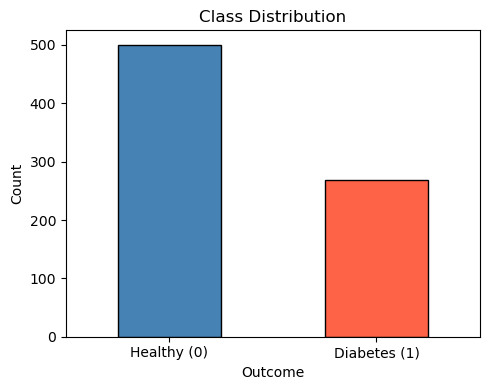

In [16]:
# Class distribution
print('Class Distribution:')
print(data['Outcome'].value_counts())

plt.figure(figsize=(5, 4))
data['Outcome'].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'], edgecolor='black'
)
plt.xticks([0, 1], ['Healthy (0)', 'Diabetes (1)'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

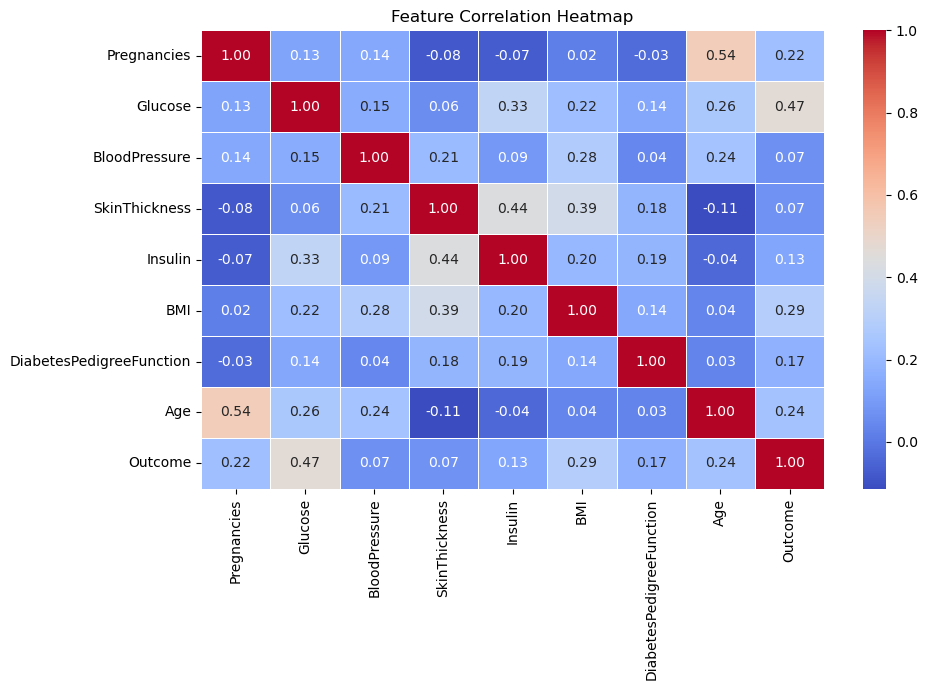

In [17]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## ✂️ 3. Split Data — Train & Test

In [18]:
target = 'Outcome'
X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape[0]} samples')
print(f'Test size : {X_test.shape[0]} samples')

Train size: 614 samples
Test size : 154 samples


## ⚙️ 4. Preprocessing — Feature Scaling

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('✅ Features scaled with StandardScaler')

✅ Features scaled with StandardScaler


## 🔍 5. Hyperparameter Tuning — GridSearchCV

In [20]:
params = {
    'n_estimators'     : [50, 100, 200, 500],
    'criterion'        : ['gini', 'entropy', 'log_loss'],
    'max_depth'        : [None, 2, 5],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=100),
    param_grid=params,
    scoring='precision',
    cv=6,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f'\n✅ Best CV Precision : {grid.best_score_:.4f}')
print(f'✅ Best Parameters   : {grid.best_params_}')

Fitting 6 folds for each of 108 candidates, totalling 648 fits

✅ Best CV Precision : 0.8031
✅ Best Parameters   : {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 100}


## 📊 6. Evaluate Model

In [21]:
y_pred = grid.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Diabetes']))

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.77      0.96      0.85        99
    Diabetes       0.87      0.47      0.61        55

    accuracy                           0.79       154
   macro avg       0.82      0.72      0.73       154
weighted avg       0.80      0.79      0.77       154



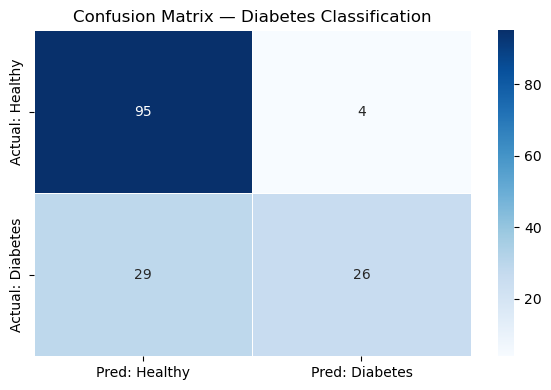

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Healthy', 'Actual: Diabetes'],
    columns=['Pred: Healthy', 'Pred: Diabetes']
)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Confusion Matrix — Diabetes Classification')
plt.tight_layout()
plt.show()

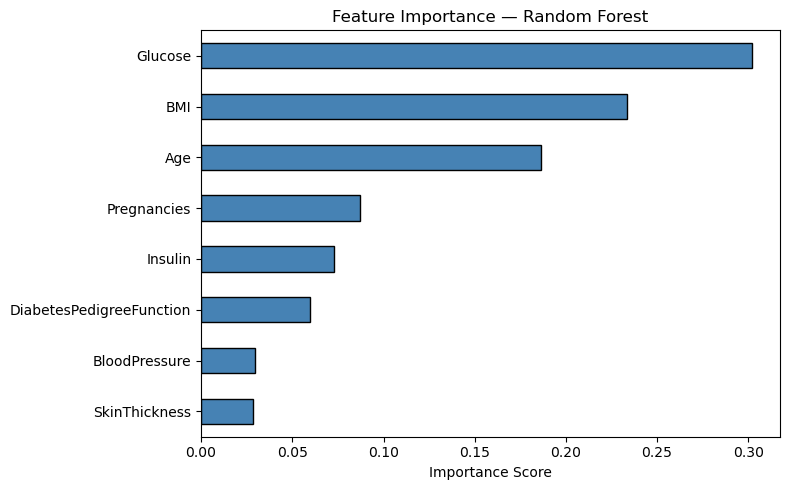

In [23]:
# Feature Importance
best_model    = grid.best_estimator_
feat_importance = pd.Series(
    best_model.feature_importances_,
    index=data.drop(target, axis=1).columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 🏁 7. Summary

| Item | Detail |
|------|--------|
| **Model** | Random Forest Classifier |
| **Tuning** | GridSearchCV (6-fold Cross Validation) |
| **Metric Optimized** | Precision |
| **Train / Test Split** | 80% / 20% |
| **Scaling** | StandardScaler |

### 🔑 Key Takeaways
- ✅ **Glucose** is the most important feature for predicting diabetes
- ✅ **BMI** and **Age** are the next most influential features
- ✅ Precision-optimized model reduces false positives — critical in medical diagnosis
- ✅ GridSearchCV automatically finds the best hyperparameter combination